In [9]:
import ipdb
import json
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from matplotlib import MatplotlibDeprecationWarning
warnings.filterwarnings('ignore', category=MatplotlibDeprecationWarning)

OUTPUT_DIR='../01-film-vs-lora-evaluation/images'

plt.style.use(['science', 'bright'])

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 9,
    'font.family': 'serif',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'text.usetex': False,
})

# width of the thesis in points
WIDTH = 441.01775

# image saving format
IMG_FORMAT = 'pdf'

In [10]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [11]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [12]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

# Accuracy comparison

In [13]:
def prepare_accuracy_data(data, target_dataset):
    results = {}
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = value['configuration']['model_name']
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])

            subset_key = f'{dataset_name} {subset_size*100:.0f}%'

            if subset_key not in results:
                results[subset_key] = {}
            if model_name not in results[subset_key]:
                results[subset_key][model_name] = {}
            if peft_method not in results[subset_key][model_name]:
                results[subset_key][model_name][peft_method] = {}
            results[subset_key][model_name][peft_method][epsilon] = accuracy
    return results

def plot_accuracy(processed_data, dataset_name, output_dir=None):
    for subset, models_data in processed_data.items():
        # Create a new figure for each subset
        fig, ax = plt.subplots(figsize=(10, 5))

        epsilons = sorted({ep for model_data in models_data.values() for method_data in model_data.values() for ep in method_data.keys()})
        pos = list(range(len(epsilons)))
        bar_width = 0.2

        for idx, (model, methods_data) in enumerate(models_data.items()):
            for jdx, (peft_method, eps_data) in enumerate(methods_data.items()):
                scores = [eps_data.get(ep, 0) for ep in epsilons]
                ax.bar([p + bar_width*(idx*len(methods_data) + jdx) for p in pos], scores, width=bar_width, label=f'{model} - {peft_method}')

        ax.set_ylabel('Accuracy')
        ax.set_title(f'Accuracy by Model, PEFT Method, and Epsilon ({subset})')
        ax.set_xticks([p + bar_width for p in pos])
        ax.set_xticklabels(epsilons)
        ax.set_ylim([0, 1])
        ax.legend(loc='lower right')

        if output_dir:
            # Ensure the output directory exists
            os.makedirs(output_dir, exist_ok=True)

            subset_str = subset.replace(' ', '_')
            filename = f'accuracy_by_model_peft_and_epsilon_{subset_str}_plot.png'
            fig.savefig(os.path.join(output_dir, filename))  # Save the current figure

    plt.show()

In [14]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    for dataset in ['cifar10', 'cifar100']:
        processed_data = prepare_accuracy_data(data, dataset)
        plot_accuracy(processed_data, dataset, output_dir=OUTPUT_DIR)

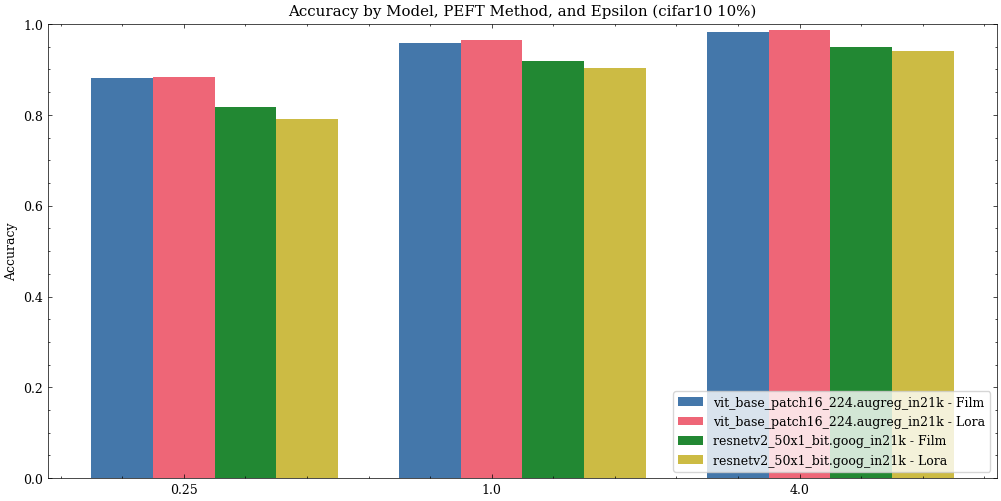

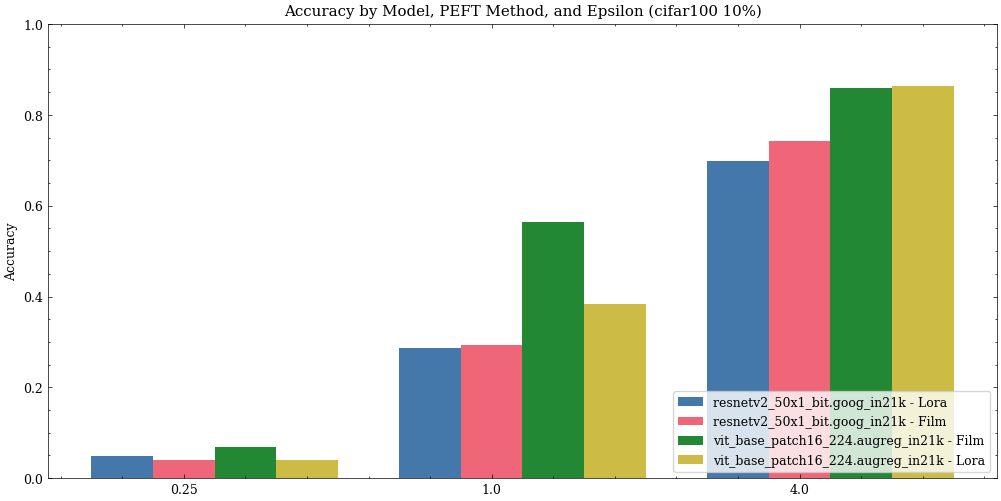

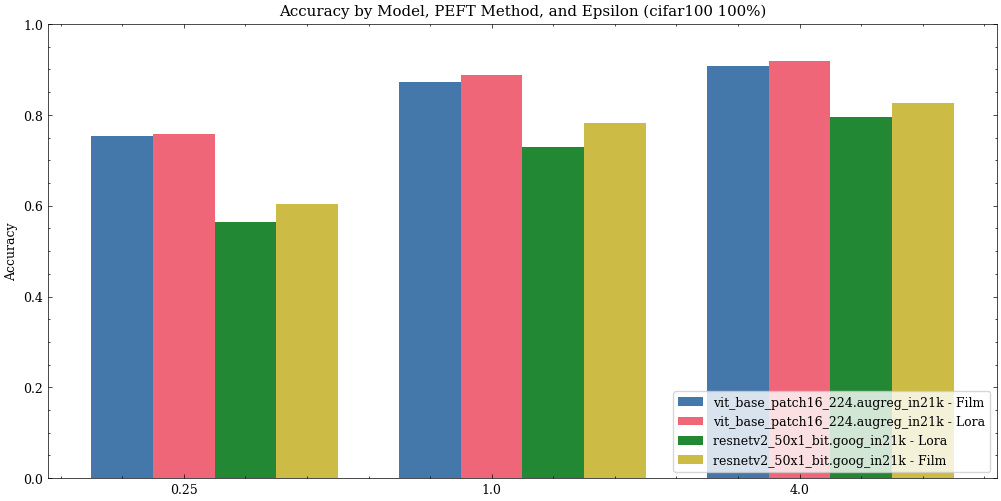

In [15]:
plot()

# Line Graphs for Accuracy Trends

In [16]:
def prepare_line_graph_data(data, target_dataset):
    df_list = []
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = value['configuration']['model_name']
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])
            df_list.append({'Model': model_name, 'PEFT Method': peft_method, 'Epsilon': epsilon, 'Accuracy': accuracy, 'Subset Size': f'{subset_size*100:.0f}%'})
    return pd.DataFrame(df_list)

def plot_accuracy_trends(df, dataset_name, subset_size, output_dir=None):
    plt.figure(figsize=(10, 6))
    unique_combinations = df[['Model', 'PEFT Method']].drop_duplicates()
    for _, row in unique_combinations.iterrows():
        model, peft_method = row['Model'], row['PEFT Method']
        subset_df = df[(df['Model'] == model) & (df['PEFT Method'] == peft_method)]
        subset_df = subset_df.sort_values(by='Epsilon')  # Sorting by Epsilon
        epsilons = subset_df['Epsilon'].tolist()  # Convert to list
        accuracies = subset_df['Accuracy'].tolist()  # Convert to list
        plt.plot(epsilons, accuracies, marker='o', label=f'{model} - {peft_method}')

    plt.ylim([0, 1])
    plt.xlabel('Epsilon')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Trends for {dataset_name.upper()} {subset_size} Subset')
    plt.legend()

    if output_dir:
        filename = f'accuracy_trend_{dataset_name}_{subset_size}_plot.png'
        plt.savefig(os.path.join(output_dir, filename))

    plt.show()


In [17]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)

    for dataset in ['cifar10', 'cifar100']:
        df = prepare_line_graph_data(data, dataset)
        for subset_size in df['Subset Size'].unique():
            subset_df = df[df['Subset Size'] == subset_size]
            plot_accuracy_trends(subset_df, dataset, subset_size, output_dir=OUTPUT_DIR)

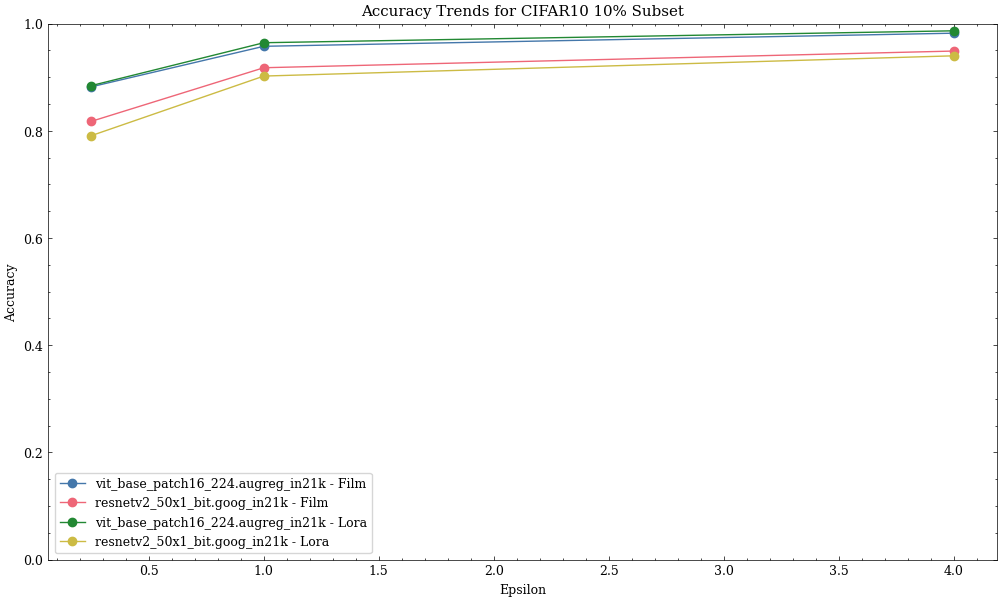

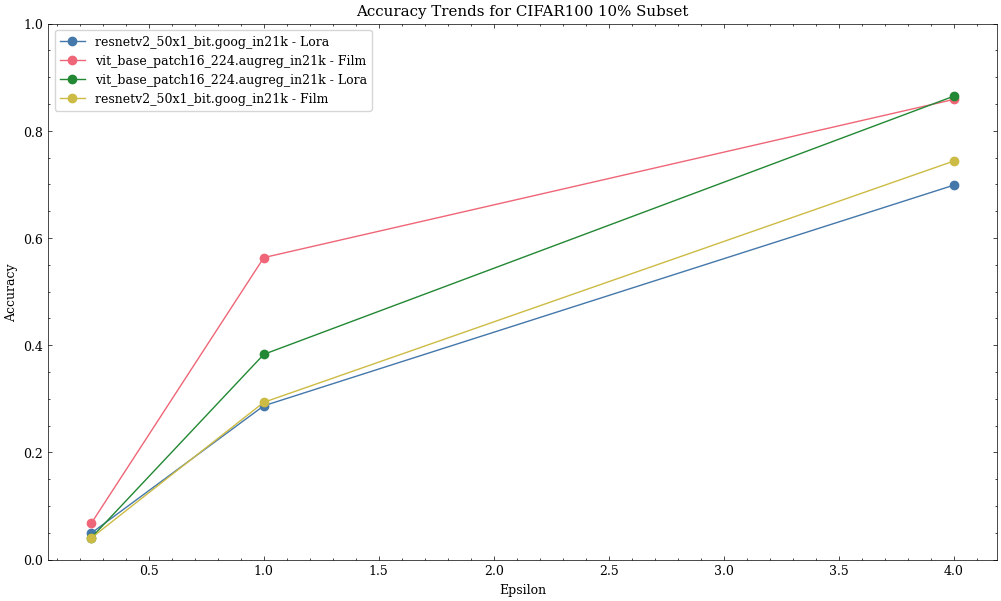

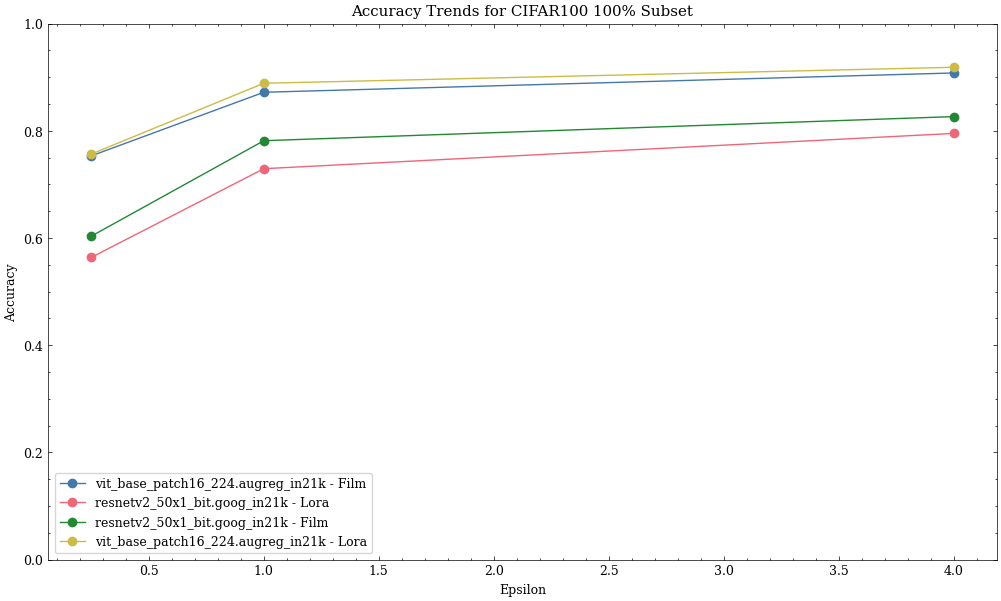

In [18]:
plot()

# 20 Trials vs 50 Trials, 10% subset

In [19]:
def prepare_data(data, target_dataset, subset_size_filter=None):
    df_list = []
    for key, value in data.items():

        if 'FullBatch' in key:
            continue

        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset and (subset_size_filter is None or subset_size == subset_size_filter):
            model_name = value['configuration']['model_name']
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])
            n_trials = value['configuration']['n_trials']
            df_list.append({'Model': model_name, 'PEFT Method': peft_method, 'Epsilon': epsilon, 'Accuracy': accuracy, 'Subset Size': f'{subset_size*100:.0f}%', 'N Trials': n_trials})

    return pd.DataFrame(df_list)

def plot_model_peft_comparison_bar_chart(df, dataset_name, model, peft_method, output_dir=None):
    unique_epsilons = sorted(df['Epsilon'].unique())
    fig, ax = get_figure((1, 1))

    bar_width = 0.35
    index = np.arange(len(unique_epsilons))

    for idx, n_trials in enumerate(sorted(df['N Trials'].unique())):
        trial_df = df[(df['Model'] == model) & (df['PEFT Method'] == peft_method) & (df['N Trials'] == n_trials)]
        accuracies = [trial_df[trial_df['Epsilon'] == ep]['Accuracy'].values[0] if not trial_df[trial_df['Epsilon'] == ep].empty else 0 for ep in unique_epsilons]
        ax.bar(index + idx * bar_width, accuracies, bar_width, label=f'{n_trials} Trials')

    ax.set_xlabel('Epsilon')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Accuracy (20 vs 50 Trials) {model} - {peft_method} - {dataset_name.upper()}')
    ax.set_xticks(index + bar_width * (len(df['N Trials'].unique()) - 1) / 2)
    ax.set_xticklabels(unique_epsilons)
    ax.set_ylim([0, 1])
    ax.legend()

    if output_dir:
        if 'resnet' in model:
            model_name = 'resnet'
        if 'vit' in model:
            model_name = 'vit'

        filename = f'accuracy_20_vs_50_trials_{dataset_name}_{model_name}_{peft_method}_10%_plot.png'
        plt.savefig(os.path.join(output_dir, filename))

    plt.show()


In [20]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/combined_data.json'
    data = read_json_data(file_path)

    for dataset in ['cifar10', 'cifar100']:
        df = prepare_data(data, dataset, subset_size_filter=0.1)
        for model in df['Model'].unique():
            for peft_method in df['PEFT Method'].unique():
                plot_model_peft_comparison_bar_chart(df, dataset, model, peft_method, output_dir=OUTPUT_DIR)


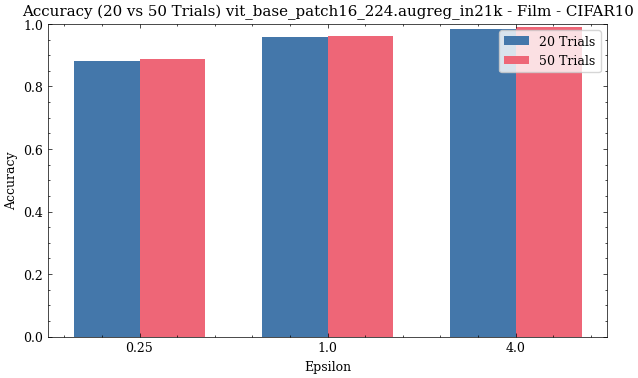

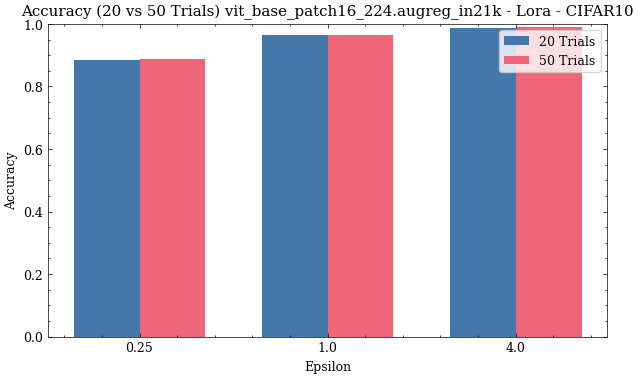

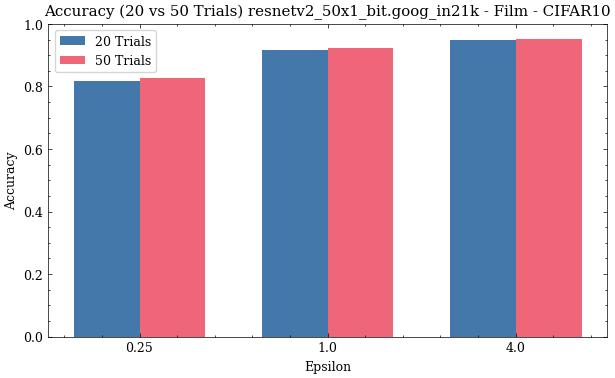

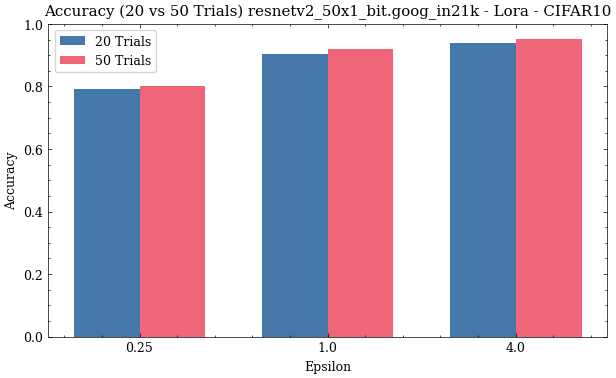

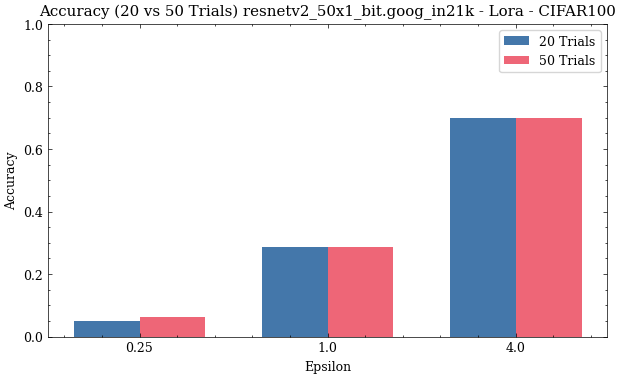

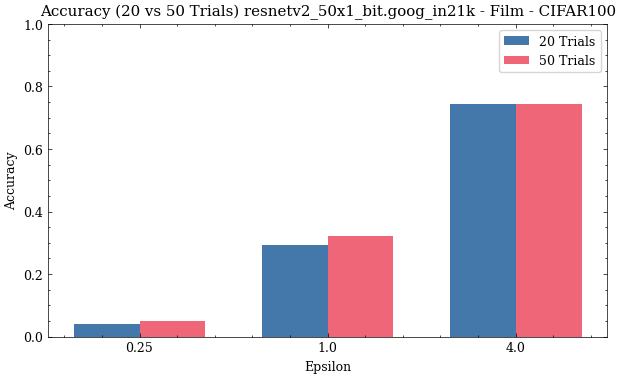

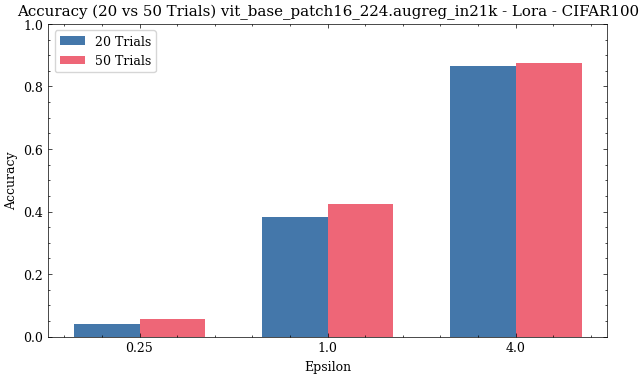

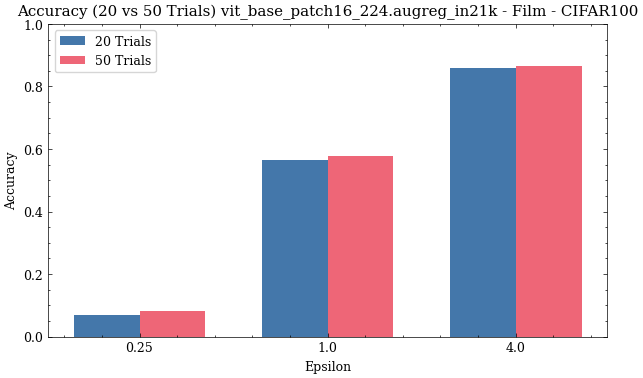

In [22]:
plot()

# Hyperparameter comparison for cifar100 10% subset vs cifar100 100% subset

In [45]:
def prepare_hyperparameters_data(data):
    rows = []
    for experiment_name, details in data.items():
        model_name = details['configuration']['model_name']
        peft = details['configuration']['peft']
        subset_size = details['configuration']['subset_size']
        dataset = details['configuration']['dataset_name']
        best_params = details['best_params']
        epsilon = details['hyperparameters']['target_epsilon']

        if dataset != 'cifar100':
            continue

        row = {
            'experiment_name': experiment_name,
            'model_name': model_name,
            'peft': peft,
            'subset_size': subset_size,
            'dataset': dataset,
            'epsilon': epsilon,
            **best_params
        }
        rows.append(row)

    return pd.DataFrame(rows)

def plot_hyperparameters_trends(df, hyperparameter, output_dir=None):
    # Calculate the max value for each epsilon group
    max_value = df[hyperparameter].max()

    for (epsilon, peft), group in df.groupby(['epsilon', 'peft']):
        fig, ax = plt.subplots(figsize=(3, 3))

        for model in group['model_name'].unique():
            model_group = group[group['model_name'] == model]

            # Extract data for 10% and 100% subsets
            data_10 = model_group[model_group['subset_size'] == 0.1]
            data_100 = model_group[model_group['subset_size'] == 1.0]

            if not data_10.empty and not data_100.empty:
                # Plotting the two points and connecting them
                ax.plot([0.1, 1.0], [data_10[hyperparameter].values[0], data_100[hyperparameter].values[0]], 
                        marker='o', linestyle='-', label=model)

        formatted_hyperparameter = hyperparameter.replace('_', ' ')
        ax.set_title(f'{formatted_hyperparameter} - Epsilon: {epsilon}, PEFT: {peft}')
        ax.set_ylabel(formatted_hyperparameter)
        ax.set_xlabel('Subset Size')
        ax.set_xticks([0.1, 1.0])
        ax.set_xticklabels(['10%', '100%'])
        ax.set_ylim(0, max_value+0.1*max_value)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

        if output_dir:
            filename = f'hyper_transfer_10%_to_100%_{formatted_hyperparameter}_{peft}_plot.png'
            fig.savefig(os.path.join(output_dir, filename))

        plt.show()

In [46]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    df = prepare_hyperparameters_data(data)
    for hyperparameter in ['epochs', 'batch_size', 'learning_rate', 'max_grad_norm']:
        # Define the number of rows and columns for subplots
        plot_hyperparameters_trends(df, hyperparameter, output_dir=OUTPUT_DIR)

/tmp/ipykernel_3571395/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


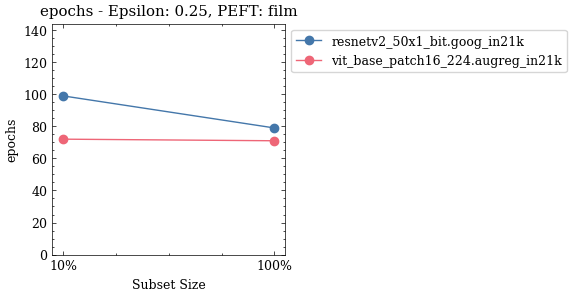

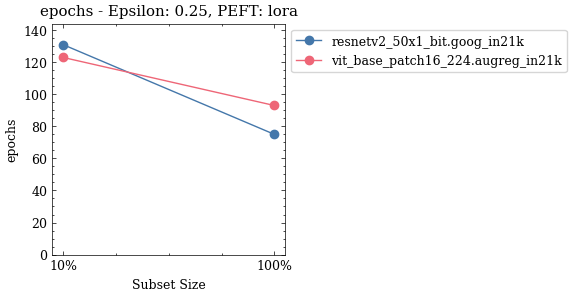

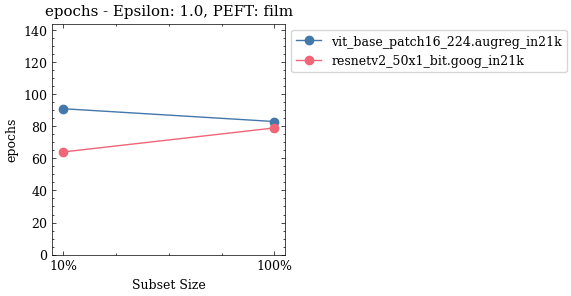

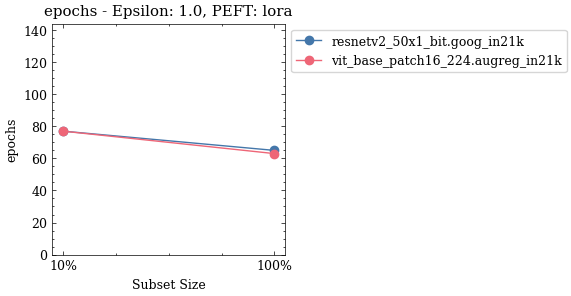

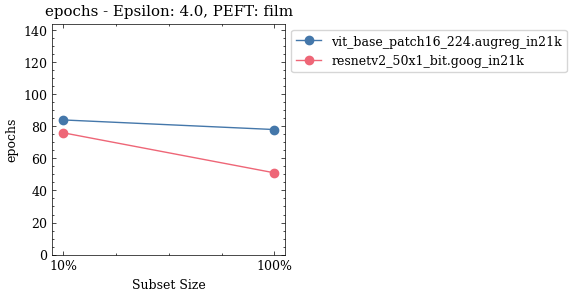

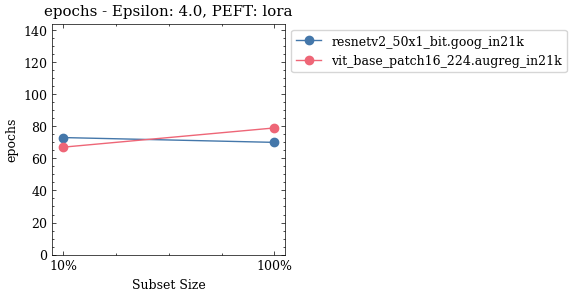

/tmp/ipykernel_3571395/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


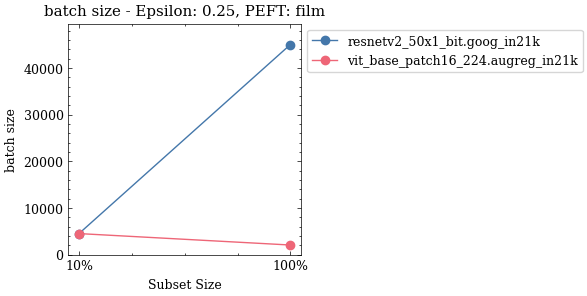

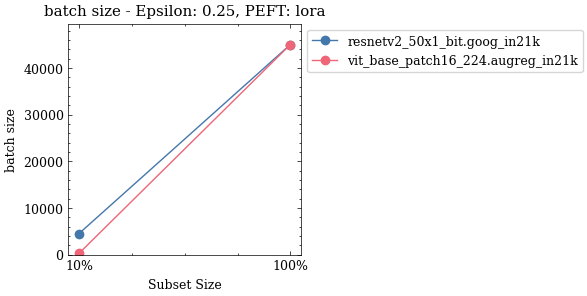

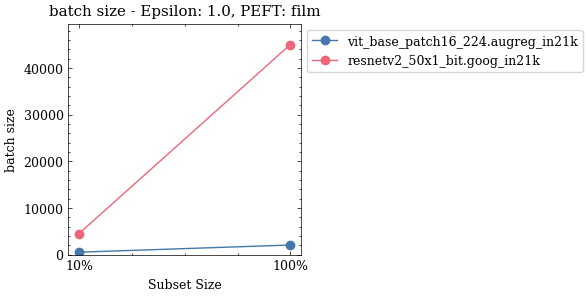

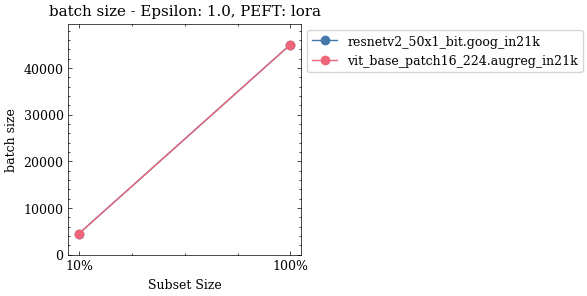

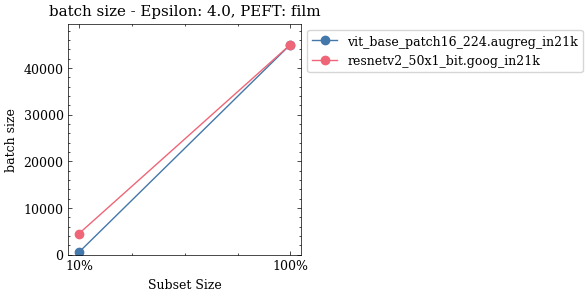

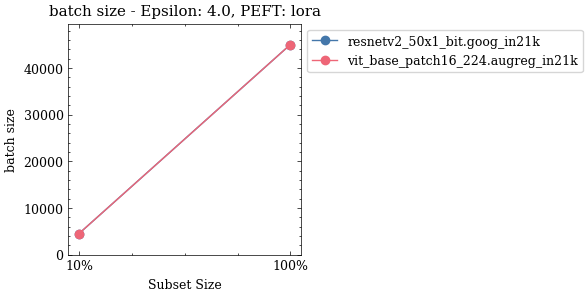

/tmp/ipykernel_3571395/2209505597.py:57: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.savefig(os.path.join(output_dir, filename))
/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


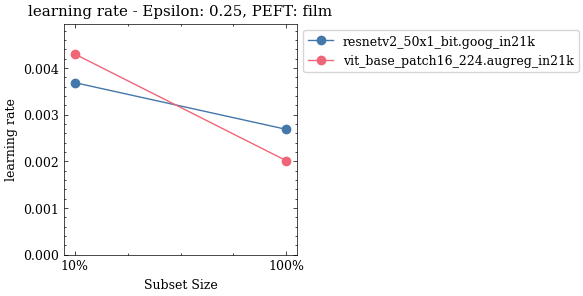

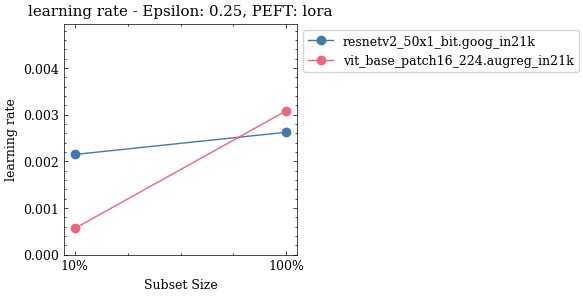

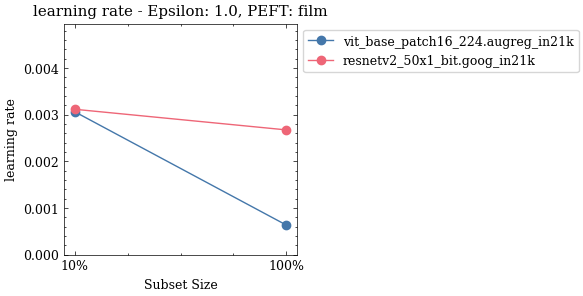

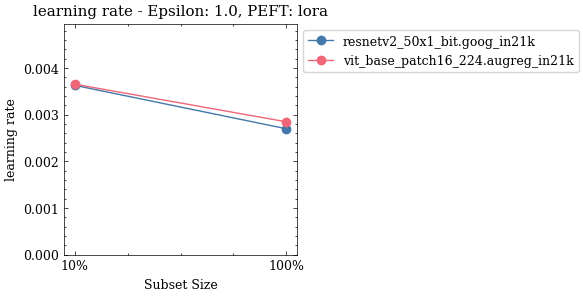

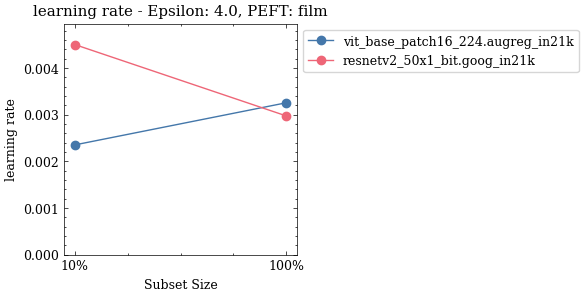

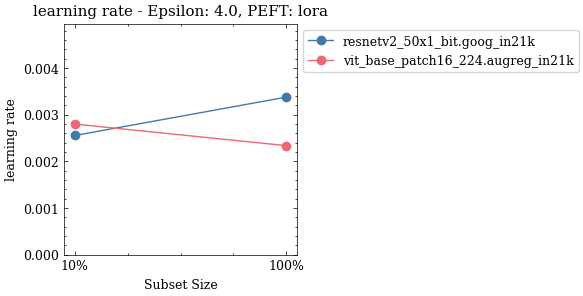

In [ ]:
plot()

# Accuracy comparison Full batch vs Optimized batch

In [17]:
def prepare_accuracy_data(data, target_dataset):
    results = {}
    for key, value in data.items():
        dataset_name = value['configuration']['dataset_name']
        subset_size = value['configuration']['subset_size']
        if dataset_name == target_dataset:
            model_name = value['configuration']['model_name']
            peft_method = value['configuration']['peft'].capitalize()
            epsilon = value['hyperparameters']['target_epsilon']
            accuracy = float(value['best_value'])

            if subset_size != 0.1:
                continue

            is_full_batch = 'FullBatch' in key

            subset_key = f'{dataset_name} {subset_size*100:.0f}%'

            if subset_key not in results:
                results[subset_key] = {}
            if model_name not in results[subset_key]:
                results[subset_key][model_name] = {}
            if peft_method not in results[subset_key][model_name]:
                results[subset_key][model_name][peft_method] = {'optimized': {}, 'full_batch': {}}
            batch_type = 'full_batch' if is_full_batch else 'optimized'
            results[subset_key][model_name][peft_method][batch_type][epsilon] = accuracy

    return results

def plot_accuracy(processed_data, dataset_name, output_dir=None):
    num_subsets = len(processed_data)
    fig, axs = plt.subplots(num_subsets, 1, figsize=(10, num_subsets * 5))
    if num_subsets == 1:
        axs = [axs]

    for ax, (subset, models_data) in zip(axs, processed_data.items()):
        epsilons = sorted({ep for model_data in models_data.values() for method_data in model_data.values() for batch_type in method_data.values() for ep in batch_type.keys()})
        pos = list(range(len(epsilons)))
        bar_width = 0.2

        for idx, (model, methods_data) in enumerate(models_data.items()):
            for jdx, (peft_method, batch_data) in enumerate(methods_data.items()):
                # Extract optimized and full batch scores
                optimized_scores = [batch_data['optimized'].get(ep, 0) for ep in epsilons]
                full_batch_scores = [batch_data['full_batch'].get(ep, 0) for ep in epsilons]
                
                # Plot optimized scores
                ax.bar([p + bar_width * (idx * len(methods_data) + jdx) for p in pos], optimized_scores, width=bar_width/2, label=f'{model} - {peft_method} (Optimized)')

                # Plot full batch scores
                ax.bar([p + bar_width * (idx * len(methods_data) + jdx) + bar_width/2 for p in pos], full_batch_scores, width=bar_width/2, label=f'{model} - {peft_method} (Full Batch)')

        ax.set_ylabel('Accuracy')
        ax.set_title(f'Full batch vs optimized accuracy by Model, PEFT Method, and Epsilon ({subset})')
        ax.set_xticks([p + bar_width for p in pos])
        ax.set_xticklabels(epsilons)
        ax.set_ylim([0, 1])
        ax.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

        if output_dir:
            subset_str = subset.replace(' ', '_')
            filename = f'accuracy_fullbatch_vs_optimized_by_model_peft_and_epsilon_{subset_str}_plot.png'
            plt.savefig(os.path.join(output_dir, filename))

    plt.tight_layout()
    plt.show()

In [18]:
def plot():
    file_path = '../01-film-vs-lora-evaluation/processed-data/combined_data.json'
    data = read_json_data(file_path)
    for dataset in ['cifar10', 'cifar100']:
        processed_data = prepare_accuracy_data(data, dataset)
        plot_accuracy(processed_data, dataset, output_dir=OUTPUT_DIR)

/tmp/ipykernel_1859909/2662017155.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


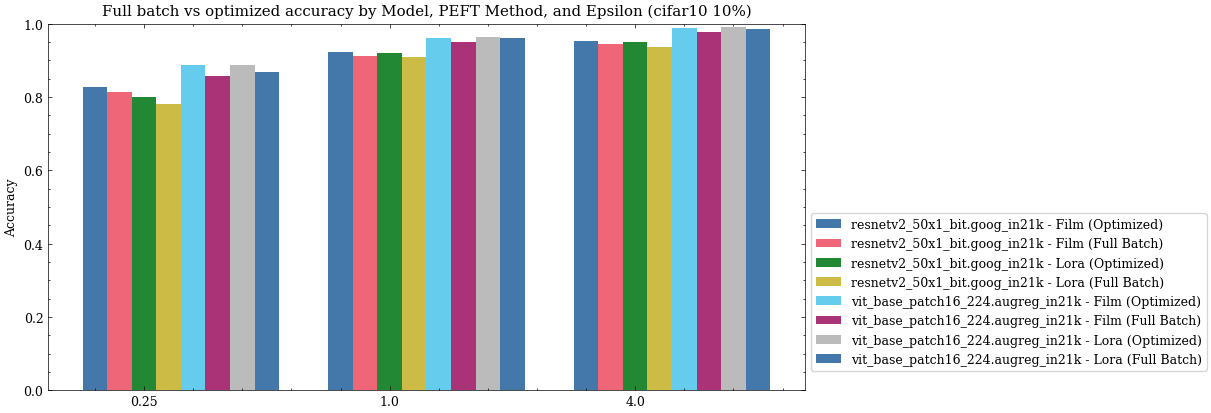

/tmp/ipykernel_1859909/2662017155.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


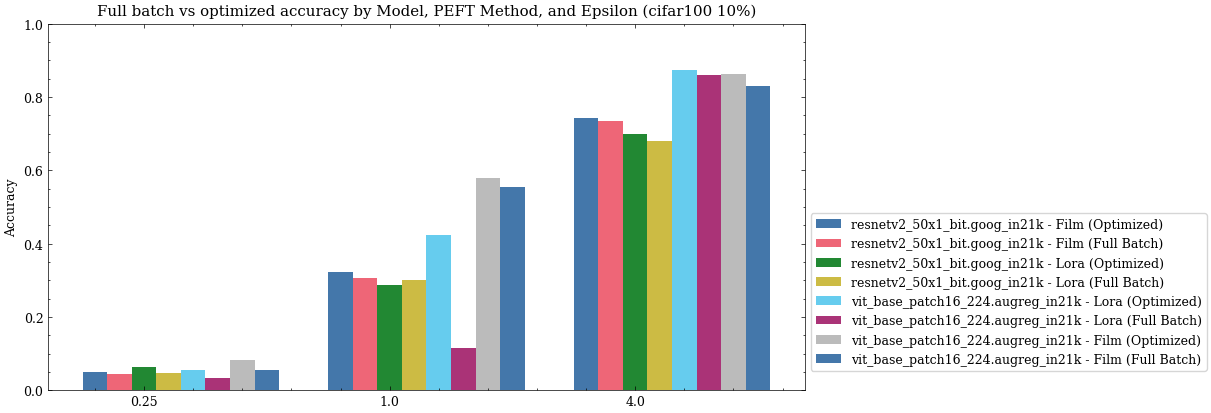

In [19]:
plot()